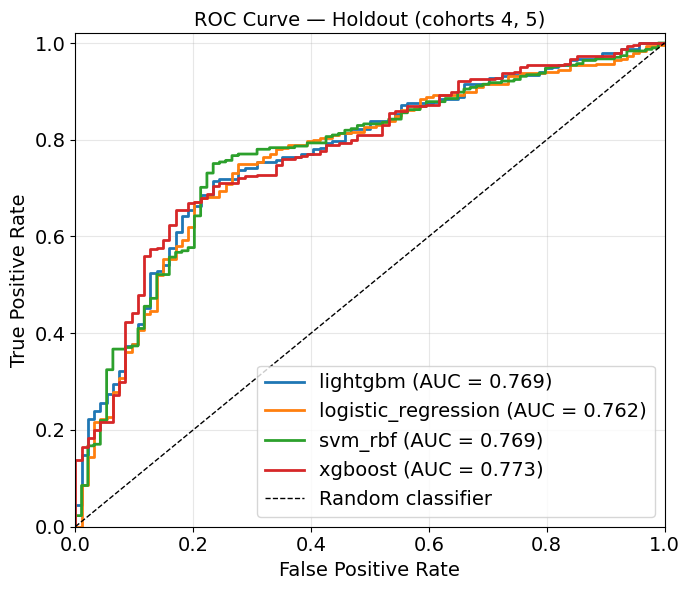

In [2]:
import glob, joblib
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

payloads = [joblib.load(f) for f in sorted(glob.glob('../results/roc_data/roc_*.joblib'))]

plt.figure(figsize=(7, 6))

for p in payloads:
    fpr, tpr, _ = roc_curve(p['y_true'], p['y_score'])
    auc = roc_auc_score(p['y_true'], p['y_score'])
    plt.plot(fpr, tpr, lw=2, label=f"{p['model_name']} (AUC = {auc:.3f})")

# Random-classifier reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve — Holdout (cohorts 4, 5)', fontsize=14)
plt.legend(loc='lower right', fontsize=14)
plt.tick_params(which='both', labelsize=14)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/ROC_comparison_plot.png', dpi=300, pil_kwargs={'compression':'png_lzw'})
plt.show()
